In [1]:
import pandas as pd 



/tmp/ipykernel_80995/2565880256.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
import numpy as np
import torch
from pykeops.torch import LazyTensor
import sys


sys.path.append("dev/survivalGPU/python")



from survivalgpu import use_cuda, device, float32, int32, int64
from survivalgpu.utils import numpy
from survivalgpu.wce_features import wce_features_batch, bspline_atoms
from survivalgpu.simulation import simulate_dataset, WCECovariate
from survivalgpu.wce import wce_R




[KeOps] Warning : Cuda libraries were not detected on the system or could not be loaded ; using cpu only mode


In [18]:
help(simulate_dataset)

Help on function simulate_dataset in module survivalgpu.simulation:

simulate_dataset(max_time, n_patients, list_covariates: list[survivalgpu.simulation.WCECovariate, survivalgpu.simulation.TimeDependentCovariate, survivalgpu.simulation.ConstantCovariate])



In [3]:

wce_covariate = WCECovariate(
    name = "testcov",
    values = [1,1.5,2,2.5,3],
    scenario_name = "exponential_scenario",
    HR_target = 1.5 

)




dataset = simulate_dataset(max_time = 365, 
                 n_patients = 100, 
                 list_covariates =  [wce_covariate])
#help(WCECovariate)




In [4]:
dataset

,patients,fup,start,stop,events,testcov
0,1,3,0,1,0,2.5
1,1,3,1,2,0,2.5
2,1,3,2,3,1,2.5
3,2,4,0,1,0,1.0
4,2,4,1,2,0,1.0
...,...,...,...,...,...,...
14781,100,340,335,336,0,0.0
14782,100,340,336,337,0,0.0
14783,100,340,337,338,0,0.0
14784,100,340,338,339,0,0.0


In [29]:
help(wce_R)

Help on function wce_R in module survivalgpu.wce:

wce_R(*, data, ids, covars, stop, doses, events, **kwargs)



In [62]:

wce_model = wce_R(
    data = dataset,
    ids = "patients",
    doses = "testcov",
    stop = "stop",
    events = "events",
    covars = None,
    cutoff = 180,
    bootstrap = 100
) 




Step 1 : Computing the WCE features... Done in 0.018s.

Step 2 : CoxPH regression... 
Pre-processing:
Working with 100 bootstrap, 1 channels, 67 death times,
3,160 rows (= observations) and 5 columns (= features).

Iteration   1 -- inf
Iteration   2 -- 2.630708e+02
Iteration   3 -- 2.603880e+02
Iteration   4 -- 2.603820e+02
Iteration   5 -- 2.603819e+02
Iteration   6 -- 2.603819e+02
Iteration   7 -- 2.603819e+02
Iteration   8 -- 2.603819e+02
Iteration   9 -- 2.603819e+02
Iteration  10 -- 2.603819e+02
Iteration  11 -- 2.603819e+02
Iteration  12 -- 2.603819e+02
Iteration  13 -- 2.603819e+02
Iteration  14 -- 2.603819e+02
Iteration  15 -- 2.603819e+02
Iteration  16 -- 2.603819e+02
Iteration  17 -- 2.603819e+02
Iteration  18 -- 2.603819e+02
Iteration  19 -- 2.603819e+02
Iteration  20 -- 2.603819e+02
Done in 0.901s.

Step 3 : Post-processing... Done in 0.001s.



In [64]:
wce_model["WCEmat"]

HR = np.exp(wce_model["WCEmat"][0].sum())
HR

wce_model["WCEmat"].shape

(100, 180)

In [ ]:
bootstrap_samples = np.random.choice(dataset['patients'].unique(), size=100, replace=True)
bootstrap_samples

bootstrap_dataset = dataset[dataset['patients'].isin(bootstrap_samples)]
bootstrap_dataset = bootstrap_dataset.loc[bootstrap_dataset.index.repeat(bootstrap_samples.tolist().count)]


array([ 46,  62,  40,  42,  55,  57,   7,  15,  61,  93,  54,  16,  62,
        95,  10,  72,  79,   8,  25,  31,  54,  31,  13,  60,  34,  76,
        52,  32,  52,  35,  43,  67,  69,  82,  77,  89,  25,  61,  55,
        14,  69,  92,  84,  86,  70,  63,  74,  59,  29,  31,   3,  66,
        50,  36,  51,  10,  40,  17,  50,  37,  18,  12,  19,  39, 100,
        70,  13,  53,  74,  94,  71,  18,  87,  23,  30,  35,  92,  74,
        93,  19,  54,  79,  64,  11,  65,  65,  58,  80,  69,  37,  28,
        61,  75,  84,  98,  78,  36,  11,  86,  87])

In [ ]:
bootstrap_samples = np.random.choice(dataset['patients'].unique(), size=100, replace=True)
bootstrap_samples

In [ ]:

ids = dataset["ids"]


KeyError: 'ids'

In [ ]:
wce_model = wce_R(
    data = dataset,
    ids = "patients",
    doses = "testcov",
    stop = "stop",
    events = "events",
    covars = None,
    cutoff = 180,
    bootstrap = 100
) 


In [17]:


data = dataset

ids = torch.tensor(data["patients"])
times = torch.tensor(data["stop"])
doses = torch.tensor(data["testcov"])
nknots = 1
cutoff = 180
order = 3



wce_features, knots = wce_features_batch(
        ids=ids,
        times=times,
        doses=doses,
        nknots=nknots,
        cutoff=cutoff,
        order=order,
    )




In [19]:
knots

tensor([ -3.,  -2.,  -1.,   0.,  90., 180., 181., 182., 183.])

In [18]:
wce_features.shape


torch.Size([14786, 5])

In [109]:
wce_features

tensor([[2.6343e+00, 3.6083e-01, 4.8814e-03,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [5.0968e+00, 8.8516e-01, 1.7980e-02,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [7.3952e+00, 1.5614e+00, 4.3161e-02,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        ...,
        [1.4166e+01, 2.9428e+01, 2.2344e+01,  ..., 5.7125e+01, 2.9301e+01,
         2.2328e+01],
        [1.2935e+01, 2.9555e+01, 2.2906e+01,  ..., 5.7070e+01, 2.9052e+01,
         2.1077e+01],
        [1.1786e+01, 2.9583e+01, 2.3483e+01,  ..., 5.6978e+01, 2.8916e+01,
         1.9725e+01]])

In [81]:
import matplotlib.pyplot as plt

In [86]:
wce_features.shape

torch.Size([16869, 5])

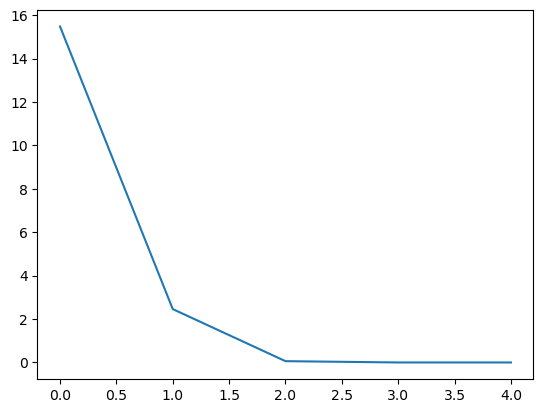

In [94]:
plt.plot(wce_features[5])

In [4]:

data = dataset.head()

ids = torch.tensor(data["patients"])
times = torch.tensor(data["stop"])
doses = torch.tensor(data["testcov"])
nknots = 1
cutoff = 180
order = 3



wce_features, knots = wce_features_batch(
        ids=ids,
        times=times,
        doses=doses,
        nknots=nknots,
        cutoff=cutoff,
        order=order,
    )


knots

KeOps LazyTensor
    formula: Var(0,2,2)
    shape: (1, 1, 2)
KeOps LazyTensor
    formula: BSpline(Var(0,2,2), (Var(1,1,0) - Var(2,1,1)), 0)
    shape: (5, 5)


tensor([ -3.,  -2.,  -1.,   0.,  90., 180., 181., 182., 183.])

In [3]:
atoms, _ = bspline_atoms(cutoff=180, order=3, knots=knots)

NameError: name 'knots' is not defined

In [117]:
bspline_atoms

<function survivalgpu.wce_features.bspline_atoms(*, cutoff, nknots=1, order=3, knots=None)>